In [13]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import linregress

import warnings
warnings.filterwarnings("ignore")

In [14]:
DATA_DIR = Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\Boxed")

In [15]:
def load_oras5_monthly_dataframe(file_token, variable_label):

    files = sorted(DATA_DIR.glob(f"*{file_token}*.nc"))

    print(f"Found {len(files)} files for {variable_label}")

    if len(files) == 0:
        raise FileNotFoundError(f"No files found containing '{file_token}'")

    values = []
    times = []

    for file in files:

        with xr.open_dataset(file) as ds:

            numeric_vars = [
                v for v in ds.data_vars
                if np.issubdtype(ds[v].dtype, np.number)
            ]

            var_name = numeric_vars[0]
            da = ds[var_name].astype(float)

            # Remove large fill values
            da = da.where(np.abs(da) < 1e10)

            # Average over all non-time dimensions
            spatial_dims = [
                d for d in da.dims
                if d.lower() not in ["time", "time_counter"]
            ]

            value = da.mean(dim=spatial_dims, skipna=True)

            values.append(float(value.values))

        year = int(file.name.split("_")[1])
        month = int(file.name.split("_")[2])

        times.append(pd.Timestamp(year=year, month=month, day=15))

    df = pd.DataFrame({
        "time": times,
        variable_label: values
    })

    df["year"] = df["time"].dt.year
    df["month"] = df["time"].dt.month

    return df

In [16]:
def add_linear_fit(ax, x, y, label_pos=(0.03, 0.95)):

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 3:
        return

    slope, intercept, r, p, stderr = linregress(x, y)
    fit = intercept + slope * x

    ax.plot(x, fit, "--", lw=1.4)

    ax.text(
        label_pos[0], label_pos[1],
        f"Slope = {slope:.3g} ± {stderr:.2g}/yr\nR² = {r**2:.3f}",
        transform=ax.transAxes,
        va="top",
        fontsize=8,
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="none")
    )

In [17]:
def shade_missing_years(ax, present_years, start_year=None, end_year=None):

    present_years = sorted(set(present_years))

    if len(present_years) == 0:
        return

    if start_year is None:
        start_year = min(present_years)

    if end_year is None:
        end_year = max(present_years)

    all_years = np.arange(start_year, end_year + 1)
    missing_years = [year for year in all_years if year not in present_years]

    for year in missing_years:
        ax.axvspan(
            year - 0.5,
            year + 0.5,
            color="red",
            alpha=0.18,
            zorder=0
        )

In [18]:
def plot_oras5_annual_and_monthly(file_token, variable_label):

    df = load_oras5_monthly_dataframe(file_token, variable_label)

    month_names = [
        "January", "February", "March", "April",
        "May", "June", "July", "August",
        "September", "October", "November", "December"
    ]

    fig = plt.figure(figsize=(14, 20))

    gs = fig.add_gridspec(
        7, 2,
        height_ratios=[1.5, 1, 1, 1, 1, 1, 1],
        hspace=0.45,
        wspace=0.25
    )

    # Annual average plot
    ax_annual = fig.add_subplot(gs[0, :])

    annual_df = (
        df.groupby("year", as_index=False)[variable_label]
        .mean()
        .dropna()
    )

    x_annual = annual_df["year"].values
    y_annual = annual_df[variable_label].values

    # Shade missing years
    shade_missing_years(
        ax_annual,
        present_years=x_annual
    )

    ax_annual.plot(
        x_annual,
        y_annual,
        marker="o",
        lw=1.6,
        markersize=4
    )

    add_linear_fit(ax_annual, x_annual, y_annual)

    ax_annual.set_title(f"{variable_label} Annual Average", fontsize=14)
    ax_annual.set_xlabel("Year")
    ax_annual.set_ylabel(variable_label)
    ax_annual.grid(alpha=0.3)

    # Monthly plots
    for month in range(1, 13):

        row = ((month - 1) // 2) + 1
        col = (month - 1) % 2

        ax = fig.add_subplot(gs[row, col])

        month_df = df[df["month"] == month].dropna()

        x = month_df["year"].values
        y = month_df[variable_label].values

        # Shade missing years
        shade_missing_years(
            ax,
            present_years=x
        )

        ax.plot(
            x,
            y,
            marker="o",
            lw=1.3,
            markersize=3
        )

        add_linear_fit(ax, x, y)

        ax.set_title(month_names[month - 1])
        ax.set_xlabel("Year")
        ax.set_ylabel(variable_label)
        ax.grid(alpha=0.3)

    fig.suptitle(
        f"{variable_label}: Annual and Monthly Linear Trends",
        fontsize=18,
        y=0.995
    )

    plt.show()

    return df

Found 798 files for SST


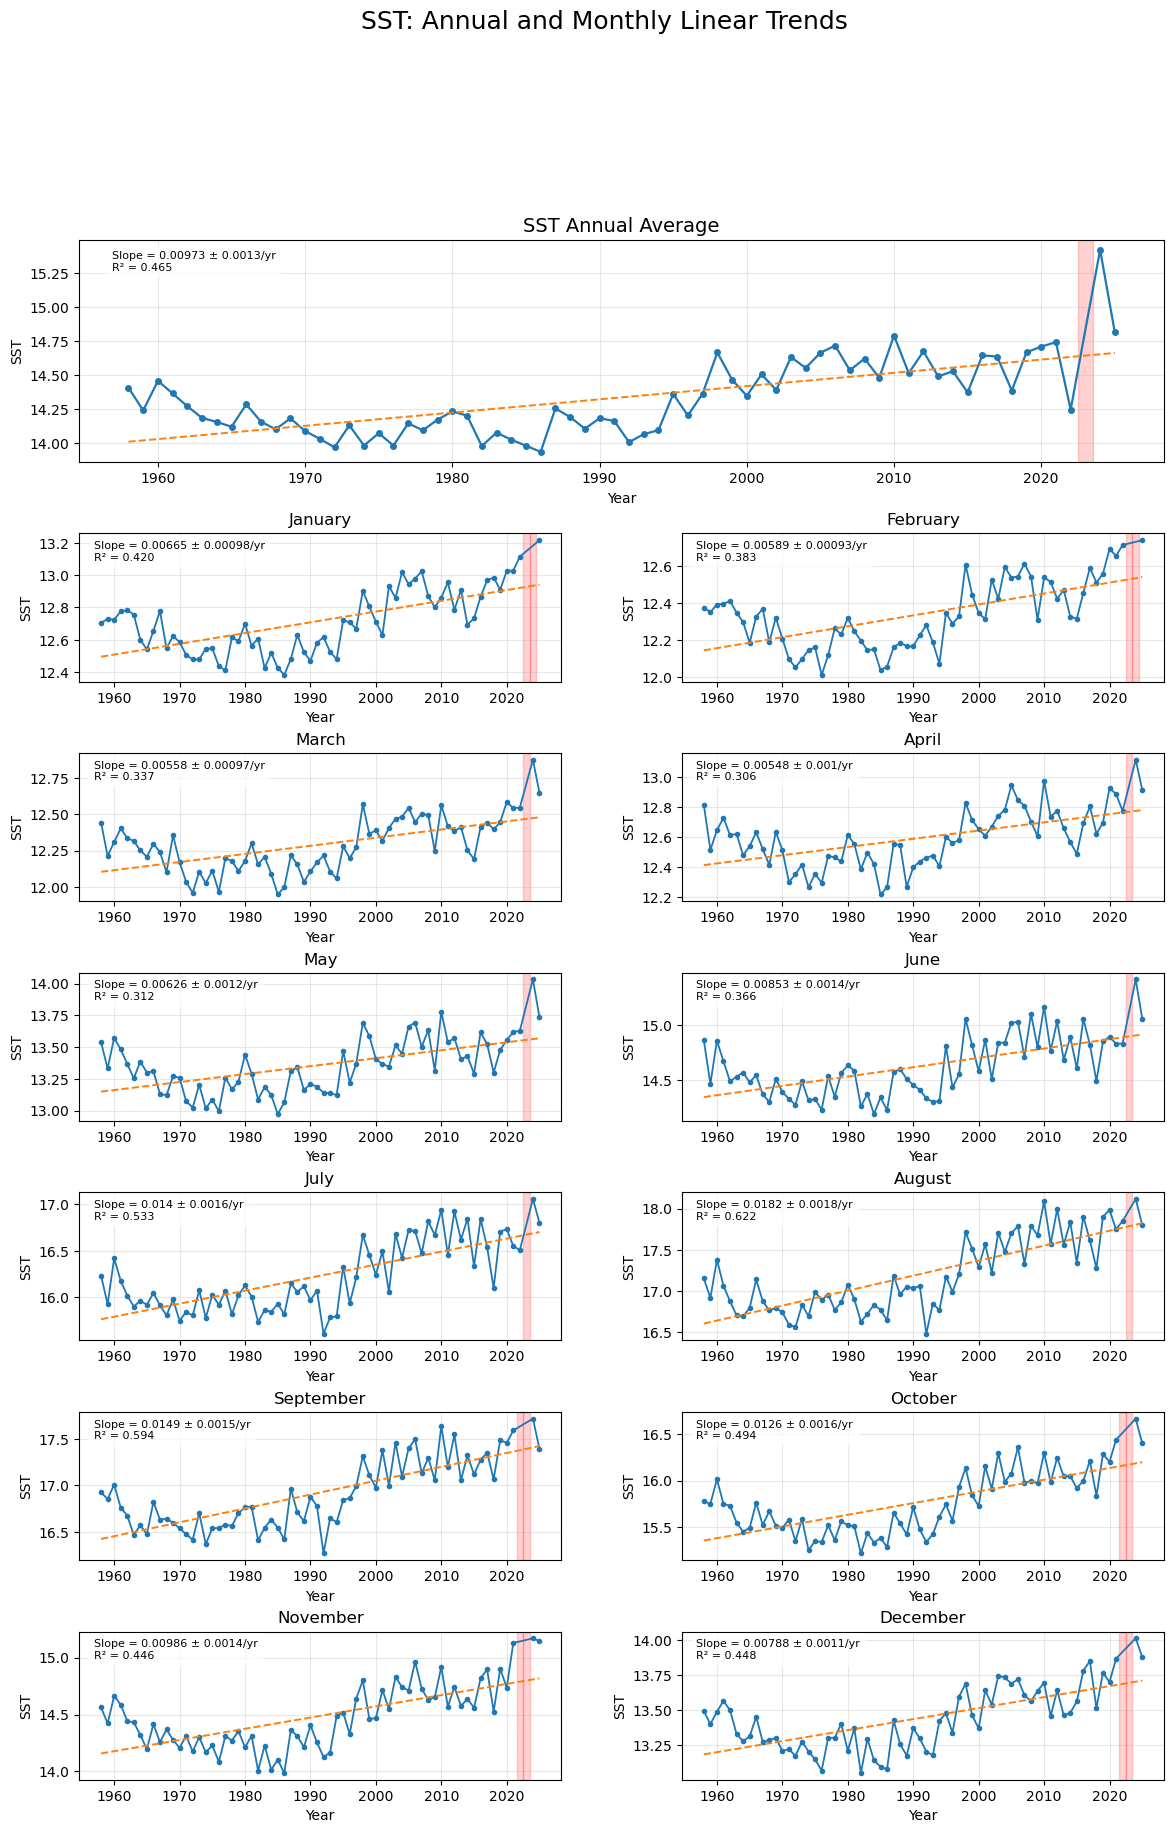

In [19]:
sst_df = plot_oras5_annual_and_monthly(
    "sst_boxed",
    "SST"
)

Found 798 files for Salinity


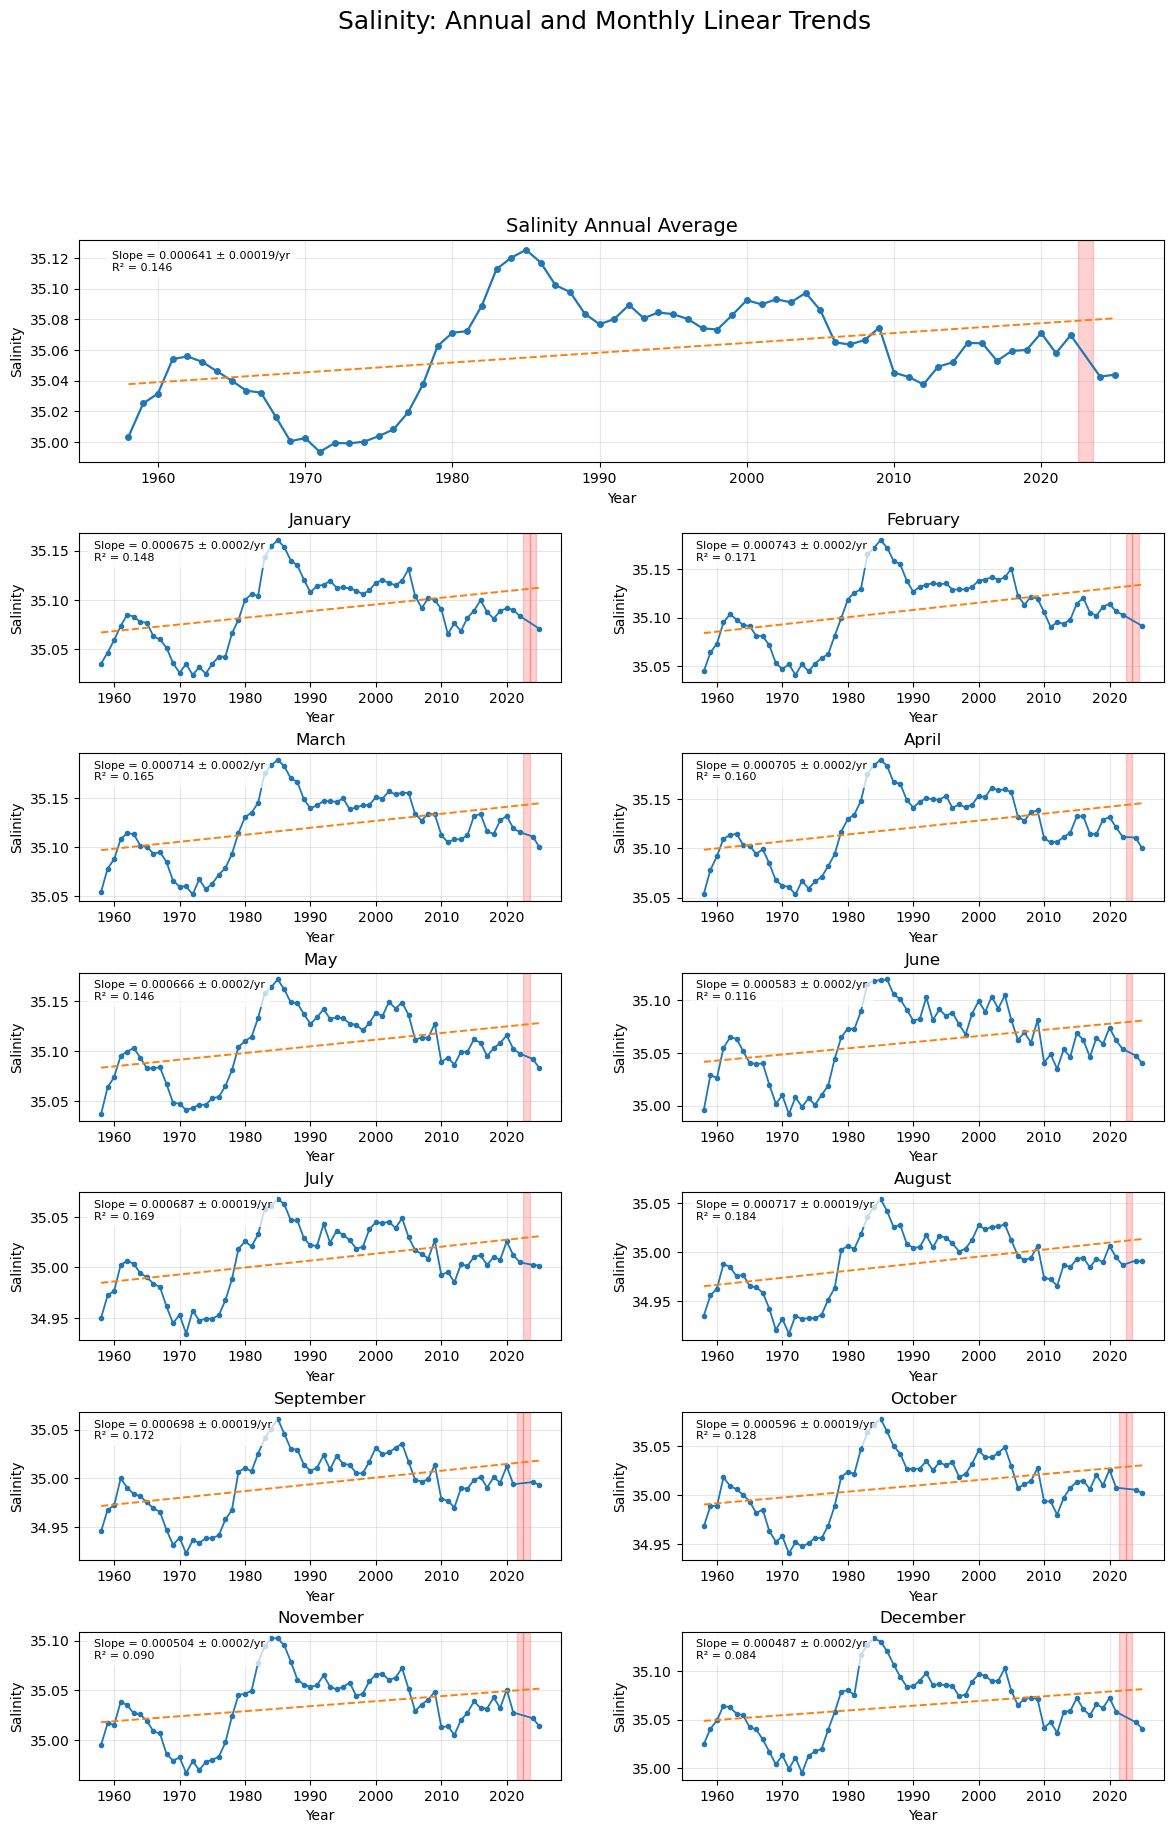

In [20]:
salinity_df = plot_oras5_annual_and_monthly(
    "so_salinity_boxed",
    "Salinity"
)

Found 798 files for Potential Temperature


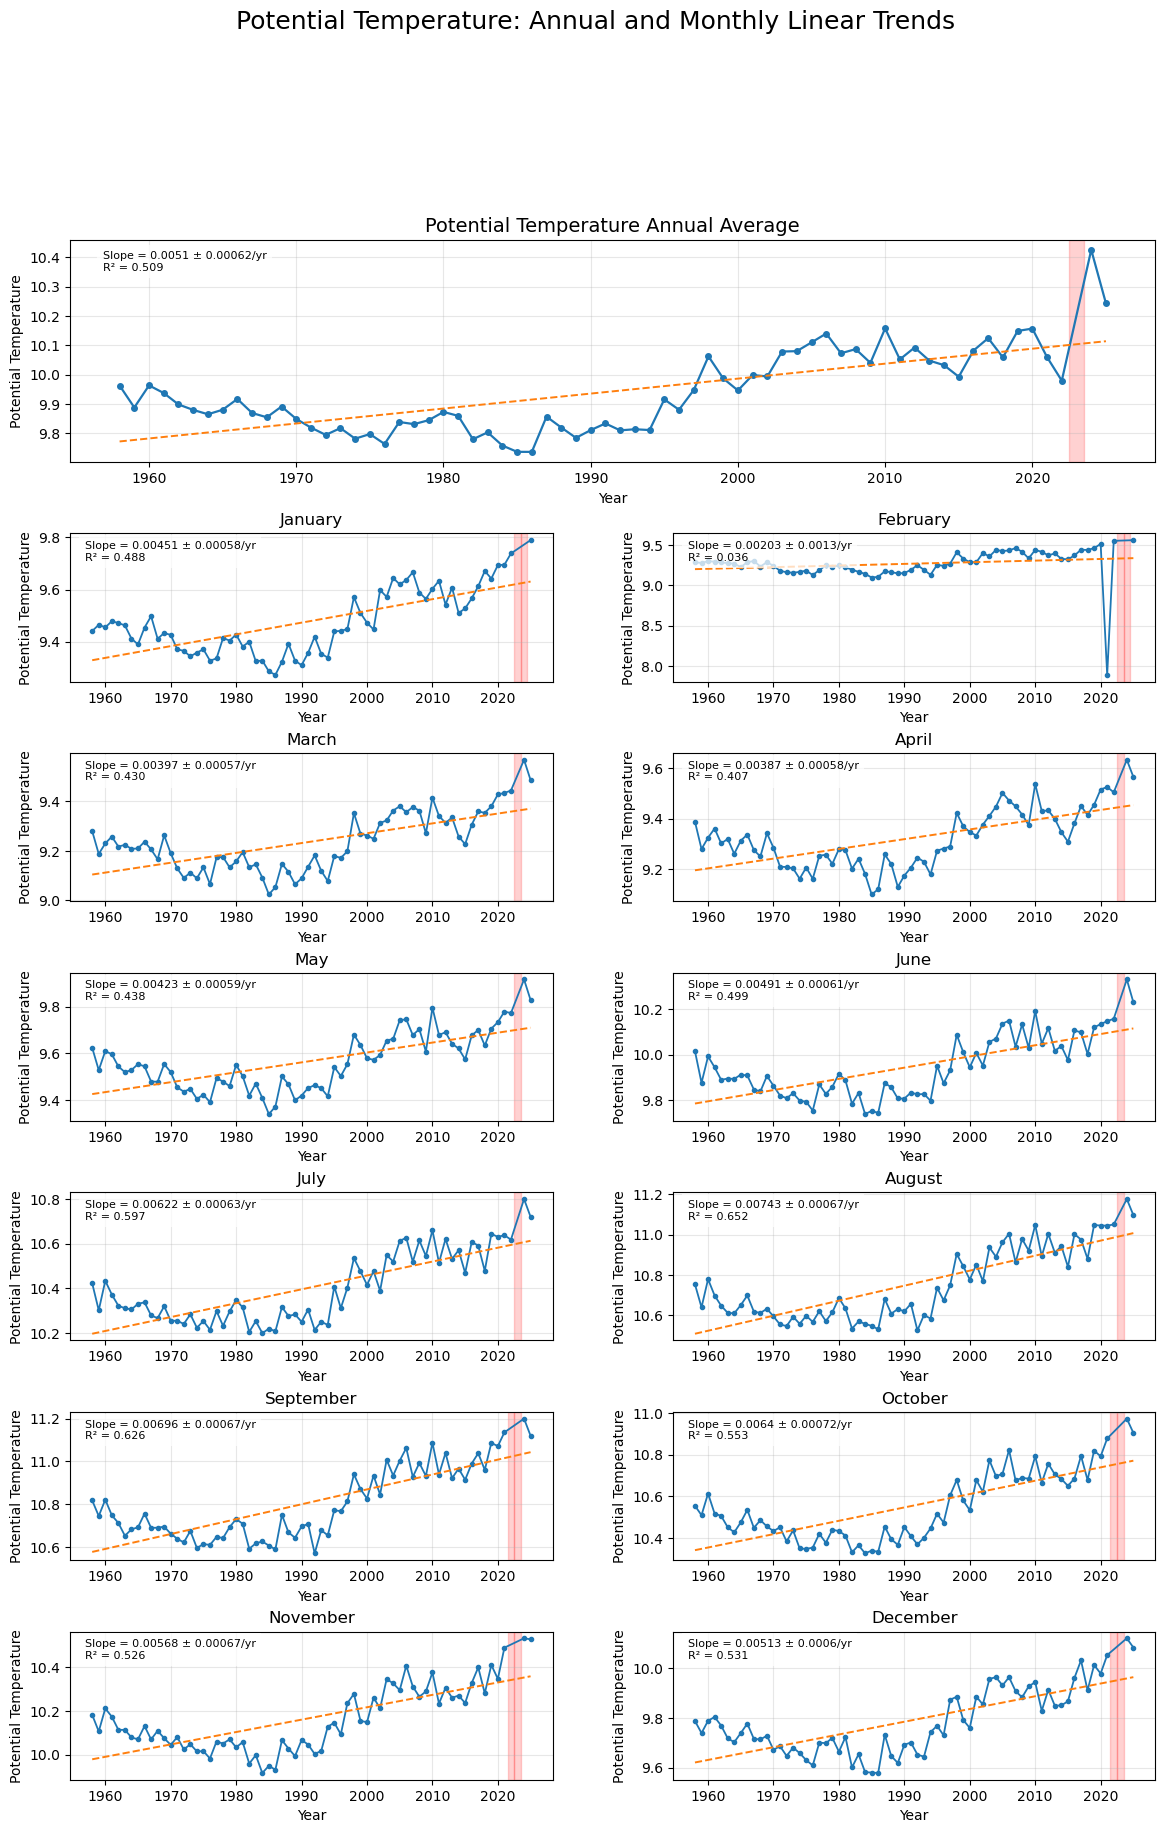

In [21]:
thetao_df = plot_oras5_annual_and_monthly(
    "thetao_potential_temperature_boxed",
    "Potential Temperature"
)

Found 798 files for U Current


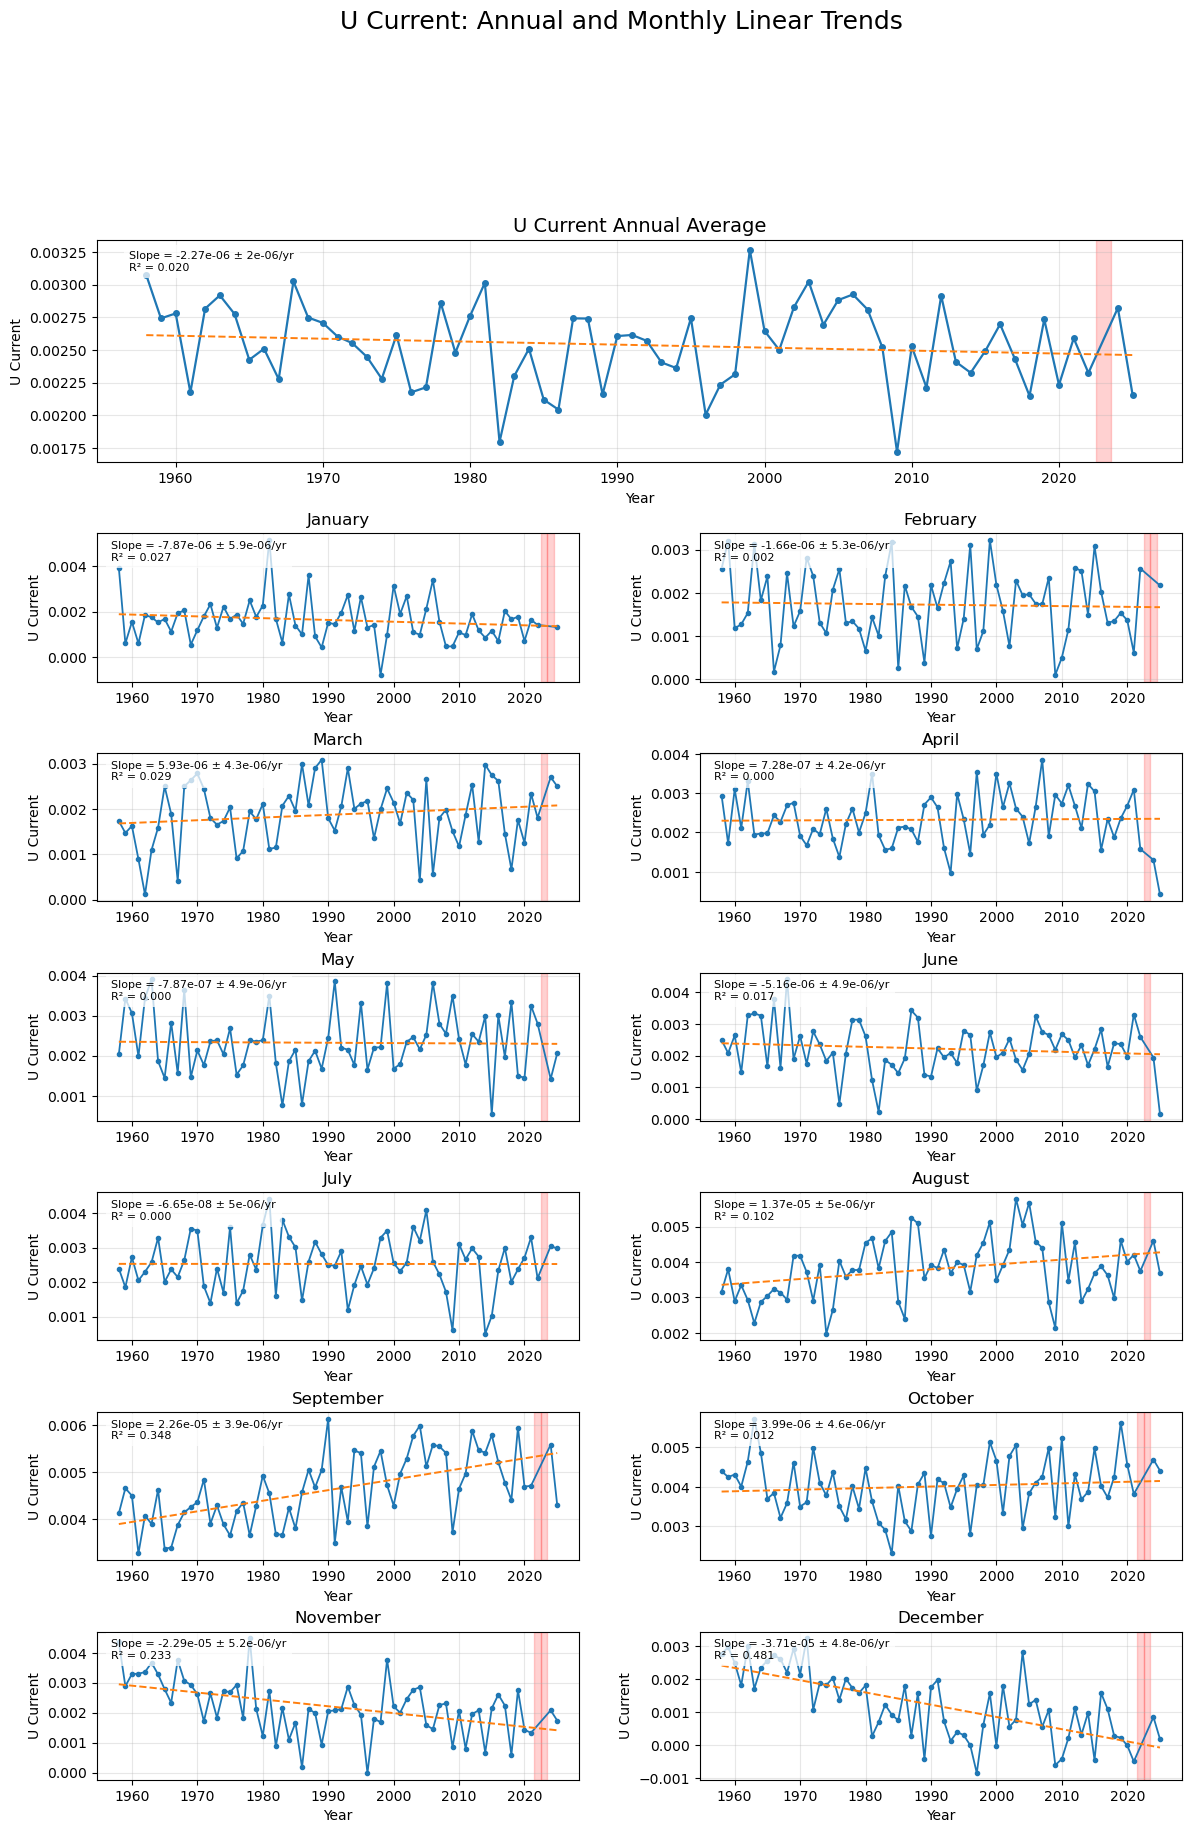

In [22]:
u_current_df = plot_oras5_annual_and_monthly(
    "u_zonal_boxed",
    "U Current"
)

Found 798 files for V Current


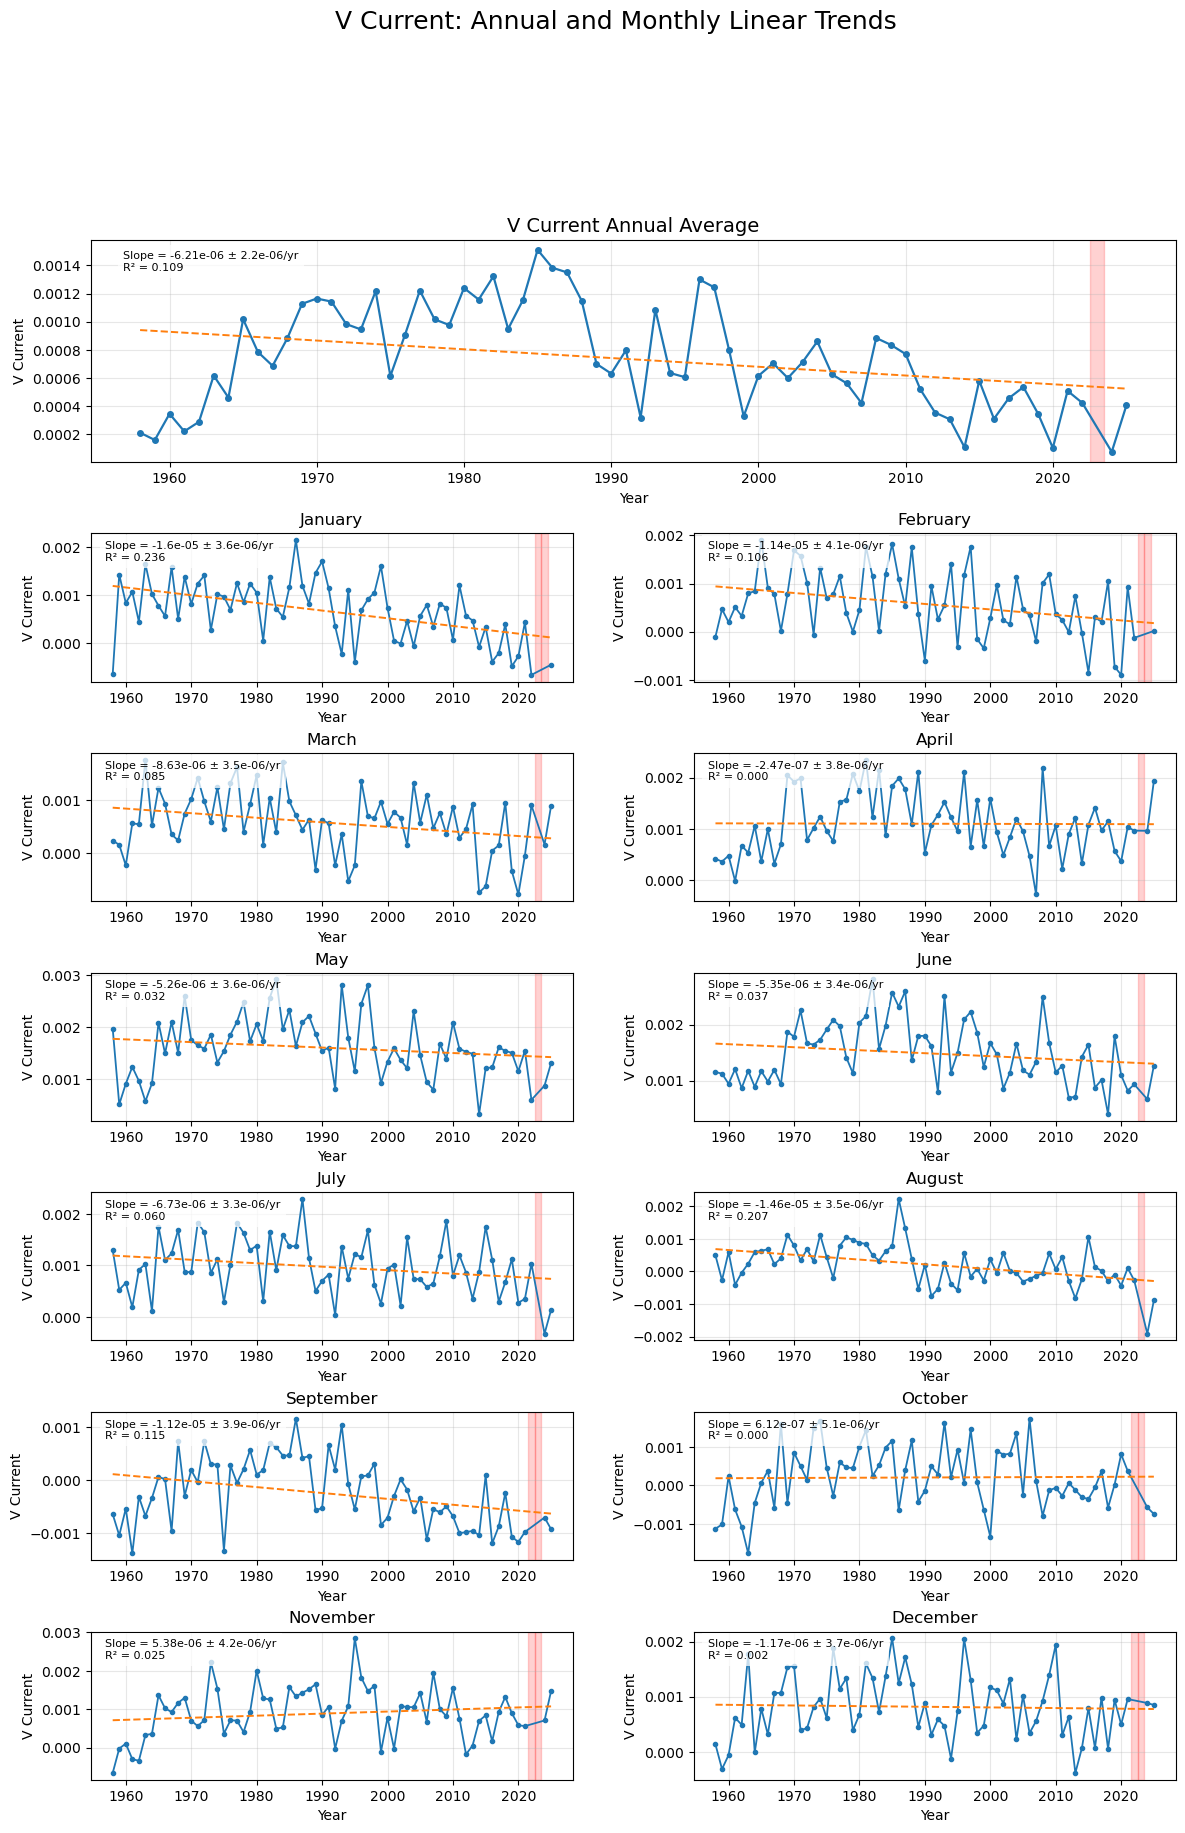

In [23]:
v_current_df = plot_oras5_annual_and_monthly(
    "v_meridional_boxed",
    "V Current"
)

Found 798 files for Net Downward Heat Flux


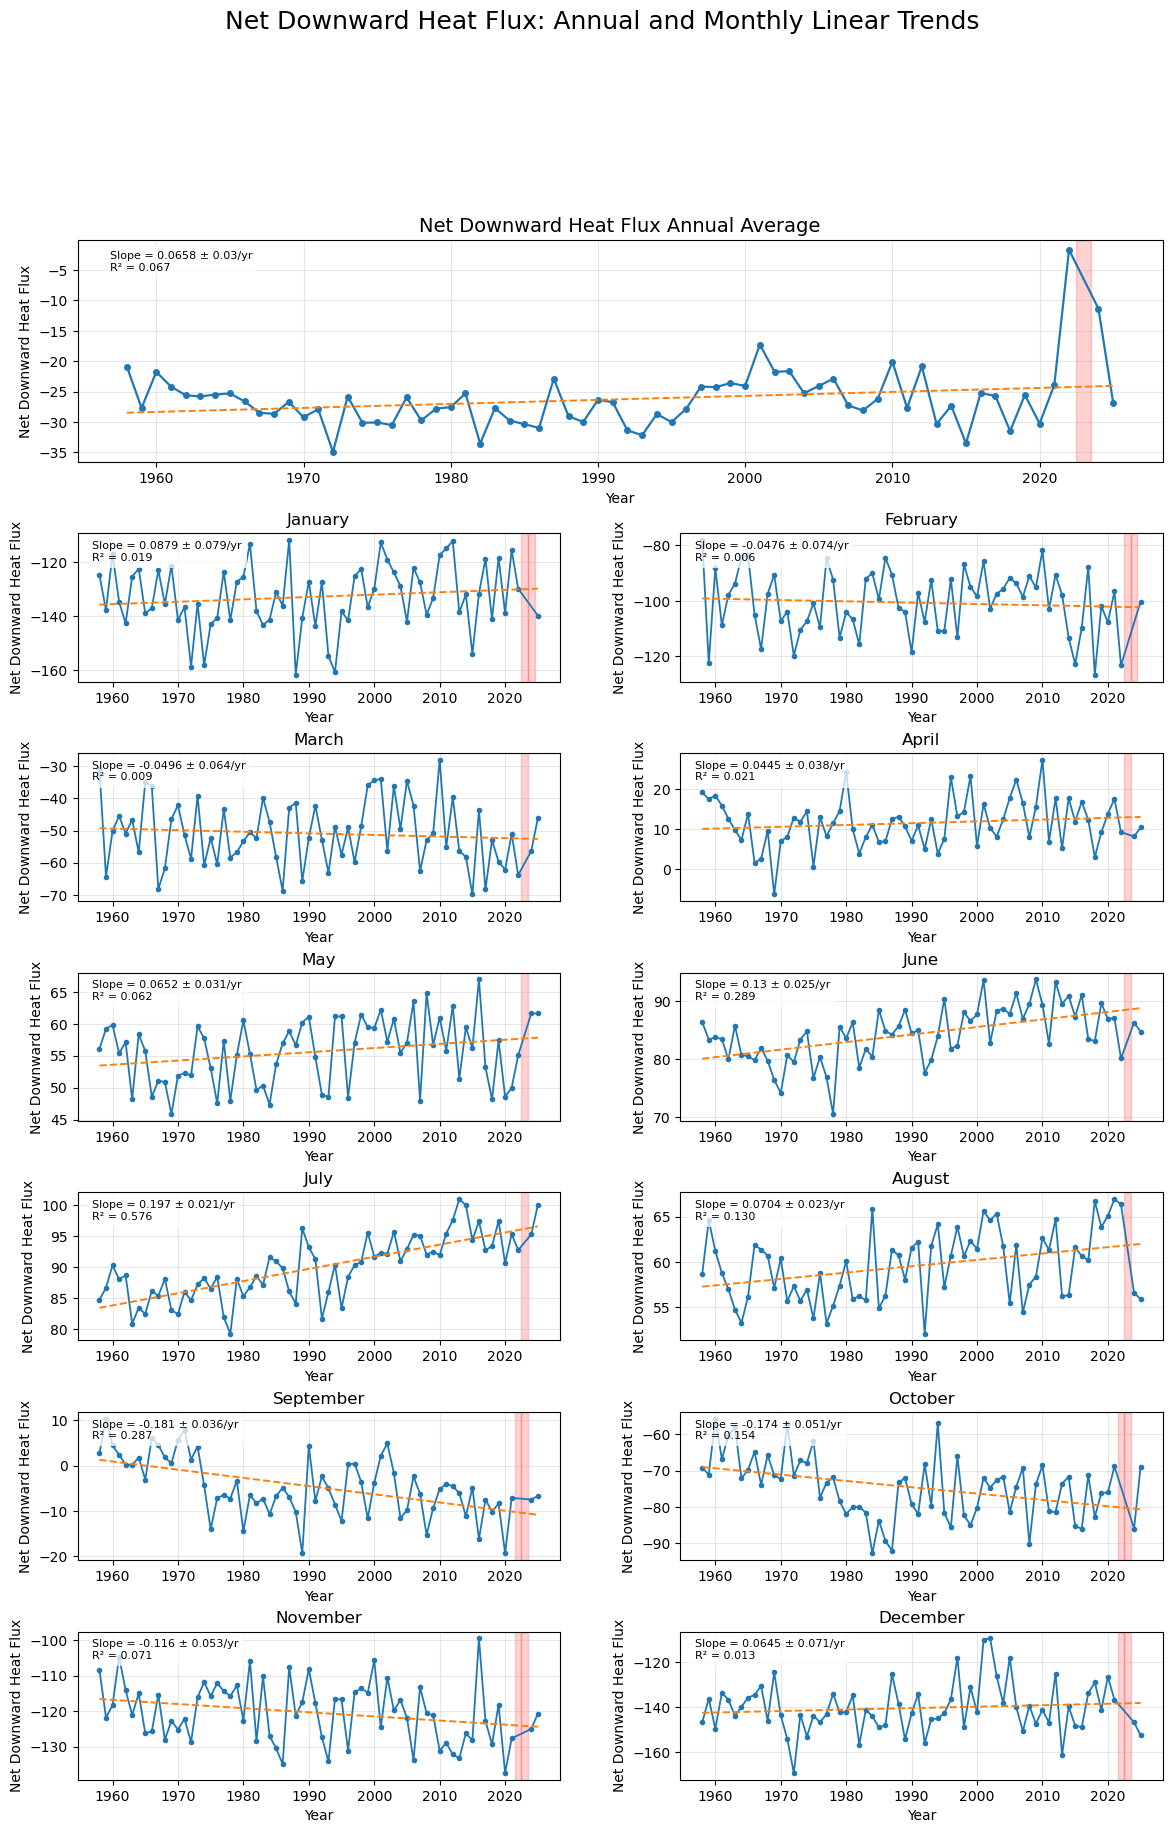

In [24]:
heat_flux_df = plot_oras5_annual_and_monthly(
    "net_downward_heat_flux_boxed",
    "Net Downward Heat Flux"
)